# Lab 01: Fitting a Line When Your Data Are Lying to You

**ASTR 457, Fall 2026 — posted Thu Sep 3, due Wed Sep 9 by Noon (fork → PR, as always)**

*Why this lab: fitting a line to contaminated data is the statistic behind real discoveries (it's how Gaia BH1's dark companion was found), and refereeing someone else's fit — including a machine's — is the skill you'll use in every collaboration, every review, and every AI-assisted analysis for the rest of your career.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `x`, `y`, `sigma_y`.
It was generated from a straight line, $y = mx + b$, with Gaussian noise of the stated
$\sigma_y$ — except that some fraction of the points are **outliers** drawn from a much
broader distribution. I know the true $m$, $b$, and outlier fraction for your dataset.
You don't, and you can't look them up, and your classmates' values are different from yours.

**How this is graded.** Not on whether your code runs — on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$m$ and $b$ are to your truth **in units of your own reported uncertainty**. Report tiny
error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.

**AI policy reminder.** Use whatever tools you like, including AI assistants — and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive fit (20%)

Load your dataset and fit a straight line by **weighted least squares**, using the reported
`sigma_y` and all the data points. Report $m \pm \sigma_m$ and $b \pm \sigma_b$, plot the
data (with error bars) and your fit, and compute the reduced $\chi^2$.

Then answer, in a few sentences: what is the reduced $\chi^2$ telling you, and why is it
doing that? Would you trust these error bars? (This fit is *supposed* to be bad. Understanding
exactly how it is bad is the point.)

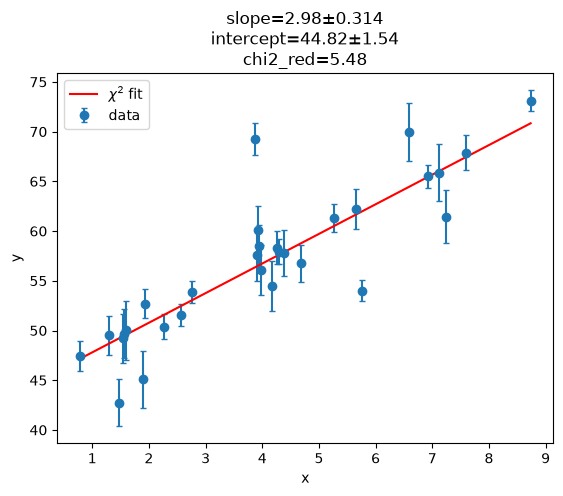

In [144]:
# Part 1: your work here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_table('../../labs/01/data/cmemery2.csv', delimiter=',')

#polyfit: Fit x, y data to a polynomial of deg=1 with weights=1/sigma
#         It minimizes the squared error E = Sum| p(x_j) - y^j |^2
#         but with weight 1/sigma, it minimizes E = Sum| (p(x_j) - y^j) / sigma |^2
#         Same as chi^2!!!!
# Returns: p: Polynomial coefficients, shape (deg+1, ) or (deg+1, K) if 2d
#          V: The covariance matrix
p_naive, cov = np.polyfit(data['x'], data['y'], 1, w=1/data['sigma_y'], cov=True)
#polyval: generate a polynomial based off of the parameters given by polyfit & x values to get points at
# Param: p: polynomial coeff
#        x: x values to evaluate p
resid = data['y'] - np.polyval(p_naive, data['x'])

#Calculate the minimized chi2 that polyfit found
chi2 = np.sum((resid / data['sigma_y']) ** 2)

# What is reduced chi2???
# Reduced chi2 = chi2 / (degrees of freedom)
#     In this case, it's linear, mx+b 
#       -> N-(fitted param) degrees of freedom 
#       -> Chi^2/(N-2)
#     Should expect this to be ~1

# chi2 = sum (residuals/sigma)^2
#     if there are N residuals, this might be expected to be ~N
#     Residuals are derived off of a difference from a mean: We don't know the true mean, mu.
#     We guess the mean, \hat mu, and obtain different values of chi2.
#     The lower the chi2, the closer \hat mu is to mu.

# If you know N-k residuals based off of \hat mu,
#     where k is number of fitted param,
#     then you are able to derive the remaining k residuals based off of known residuals alone.
#     Therefore, N-k degrees of freedom.

chi2_red = chi2 / (len(data) - 2)

plt.title(f"slope={p_naive[0]:.2f}"+r"$\pm$"+f"{np.sqrt(cov[0,0]):.3g}\n"+
          f"intercept={p_naive[1]:.2f}"+r"$\pm$"+f"{np.sqrt(cov[1,1]):.3g}\n" +
          f"chi2_red={chi2_red:.2f}")
xx = np.linspace(min(data['x']), max(data['x']), 200)
plt.errorbar(data['x'], data['y'], yerr=data['sigma_y'], fmt='o', capsize=2, label='data')
plt.plot(xx, np.polyval(p_naive, xx), 'r-', label=r'$\chi^2$ fit')
plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.show()

**ANSWER (a few sentences):**

Reduced chi2 is $\sum_i(\text{residuals}_i / \sigma_i)^2 / (\text{degrees of freedom})$. It tells you the wellness of fit by the model. 
1. For chi2_red == 1, it's a good fit
2. For chi2_red < 1, this means either sigma is too large or residuals are small. This means that the model is overestimating sigma or is trying too hard to fit noise
4. For chi2_red > 1, sigma is either small or the residuals are large, and the model is incorrect or sigma is underestimated.

So in this case the chi2_red is 5.48. This is kind of big, but not that big. I think this comes from both small sigmas and large residuals, which is making the summation in the calculation for chi2_red large. This chi2_red is just telling us that the fit is trying to take into account the outliers.

I think in general this fit isn't trustworthy since it's based off of data that is contaminated. However, the line looks similar to how i would draw through it, so maybe if i did some other fitting schemes and got the same thing, then i would be happier with it. I might say that the line that I would draw is probably within the error that this fit gives; i would draw it slightly steeper since i would disregard some points as outliers. 

## Part 2: A fit you can defend (40%)

Now deal with the outliers. Do this **two ways**:

1. **Sigma-clipping**: iteratively remove points that are discrepant with the fit, refit,
   and repeat until it converges. Be explicit about your clipping threshold and why you chose it.
2. **A mixture model**: model each point as coming from either the line (with its stated
   $\sigma_y$) or from a broader outlier distribution, and maximize the appropriate likelihood
   (see Hogg, Bovy & Lang 2010, §3, for the canonical treatment — this is the same problem
   with different numbers).

For each method report $m \pm \sigma_m$, $b \pm \sigma_b$, and (for the mixture) your
estimate of the outlier fraction. Then commit to a **final answer** — one set of numbers
you'd put in a paper — and justify the choice. State clearly how you estimated your
uncertainties and why you believe them.

1.85-sigma clip: slope=3.17, intercept=44.51, chi2_red=0.67, clipped 5 of 30 points
3-sigma clip: slope=3.21, intercept=44.06, chi2_red=1.18, clipped 2 of 30 points


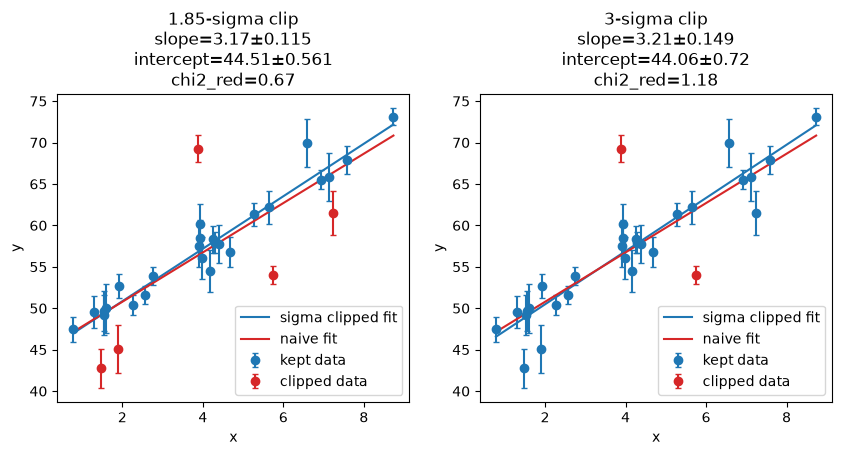

In [86]:
# Part 2: your work here

#Sigma clipping

k=3

def sigma_clip_fit(x, y, sigma, k, max_iter=10):
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        p, cov = np.polyfit(x[mask], y[mask], 1, w=1/sigma[mask], cov=True)
        resid = (y - np.polyval(p, x)) / sigma
        new_mask = np.abs(resid) < k
        if np.array_equal(new_mask, mask):
            break
        mask = new_mask
    return p, mask, cov

fig, ax = plt.subplots(1, 2, figsize = (10,4))
for i, k in enumerate([1.85, 3]):
    p_clip, mask, cov_clip = sigma_clip_fit(data['x'], data['y'], data['sigma_y'], k)
    resid = data['y'][mask] - np.polyval(p_clip, data['x'][mask])
    chi2_red_clip = np.sum((resid / data['sigma_y'][mask]) ** 2) / (mask.sum() - 2)
    print(f"{k}-sigma clip: slope={p_clip[0]:.2f}, intercept={p_clip[1]:.2f}, "
        f"chi2_red={chi2_red_clip:.2f}, clipped {(~mask).sum()} of {len(data)} points")

    ax[i].errorbar(data['x'][mask], data['y'][mask], yerr=data['sigma_y'][mask], 
                c='tab:blue', fmt='o', capsize=2, label='kept data')
    ax[i].plot(data['x'], np.polyval(p_clip, data['x']), 
            c='tab:blue', label='sigma clipped fit')
    ax[i].errorbar(data['x'][~mask], data['y'][~mask], yerr=data['sigma_y'][~mask], 
                c='tab:red', fmt='o', capsize=2, label='clipped data')
    ax[i].plot(data['x'], np.polyval(p_naive, data['x']), 
            c='tab:red', label='naive fit')
    ax[i].set_xlabel('x'); ax[i].set_ylabel('y'); ax[i].legend()

    ax[i].set_title(f"{k}-sigma clip\n"+
            f"slope={p_clip[0]:.2f}"+r"$\pm$"+f"{np.sqrt(cov_clip[0,0]):.3g}\n"+
            f"intercept={p_clip[1]:.2f}"+r"$\pm$"+f"{np.sqrt(cov_clip[1,1]):.3g}\n" +
            f"chi2_red={chi2_red_clip:.2f}")

plt.show()

In [ ]:
#mixture modelling

from scipy.optimize import minimize
from scipy.stats import norm

def neg_log_likelihood(theta, x, y, sigma):
    m, b, Pb, Yb, lnVb = theta
    Pb = np.clip(Pb, 1e-6, 1 - 1e-6)
    Vb = np.exp(lnVb)
    model = m * x + b
    good = (1 - Pb) * norm.pdf(y, loc=model, scale=sigma)
    bad_pop = Pb * norm.pdf(y, loc=Yb, scale=np.sqrt(Vb + sigma**2))
    return -np.sum(np.log(good + bad_pop + 1e-300))

#Use k sigma clip for a initial guess
theta0 = [p_clip[0], p_clip[1], 0.2, np.mean(data['y']), np.log(50.0)]
result = minimize(neg_log_likelihood, theta0, args=(data['x'], data['y'], data['sigma_y']), method='Nelder-Mead')
m_mix, b_mix, Pb_mix, Yb_mix, lnVb_mix = result.x

#----------------------------------------------
#bootstrap for uncertainty


rng_bs = np.random.default_rng()
n_boot = 1000

# resample (x, y) pair with replacement, refit mixture model each time
boot_slopes = np.empty(n_boot)
boot_intercepts = np.empty(n_boot)
boot_outlier_fraction = np.empty(n_boot)
n = len(data)
for j in range(n_boot):
    idx = rng_bs.integers(0, n, size=n)
    result_ = minimize(neg_log_likelihood, theta0, 
                       args=(data['x'][idx], data['y'][idx], data['sigma_y'][idx]), method='Nelder-Mead')

    m_mix_, b_mix_, Pb_mix_, Yb_mix_, lnVb_mix_ = result_.x
    boot_slopes[j] = m_mix_
    boot_intercepts[j] = b_mix_
    boot_outlier_fraction[j] = Pb_mix_
sigma_m = np.std(boot_slopes, ddof=1)
sigma_b = np.std(boot_intercepts, ddof=1)
sigma_Pb = np.std(boot_outlier_fraction, ddof=1)

#This code takes 5 minutes

mixture fit: slope=3.22 +/- 0.17, intercept=44.03 +/- 0.79, outlier fraction=0.11 +/- 0.24
slopes bootstrap 68% [3.03, 3.34]
intercenpts bootstrap 68% [43.39, 44.87]
P bootstrap 68% [0.04, 0.18]


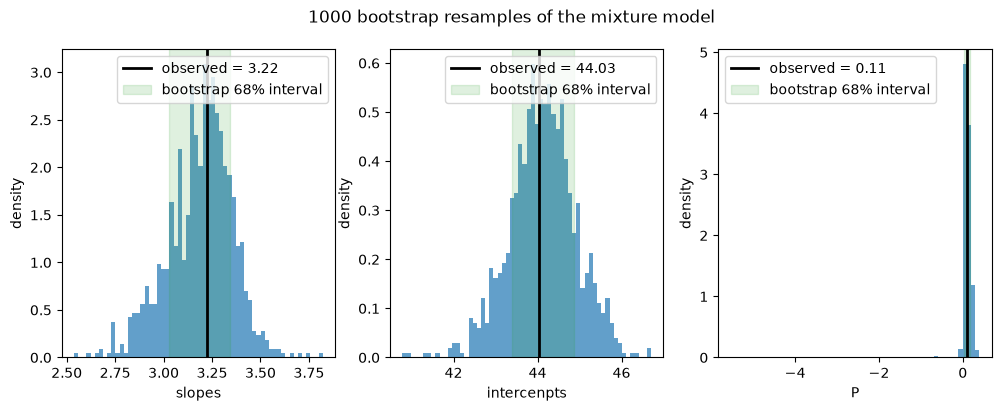

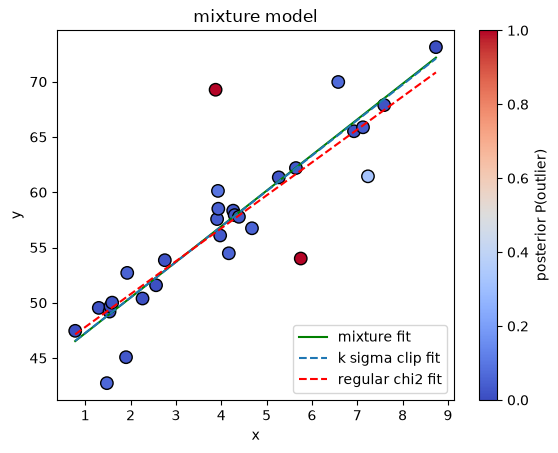

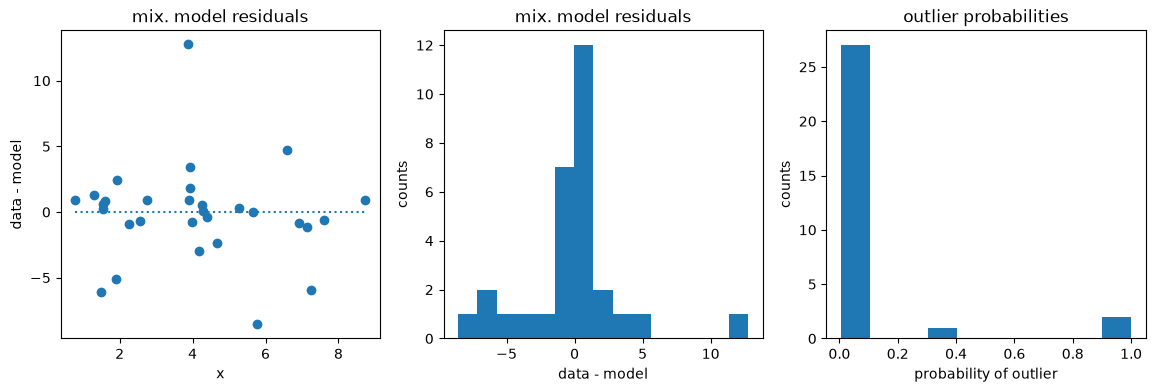

In [59]:
print(
    f"mixture fit: "
    f"slope={m_mix:.2f} +/- {sigma_m:.2f}, "
    f"intercept={b_mix:.2f} +/- {sigma_b:.2f}, "
    f"outlier fraction={Pb_mix:.2f} +/- {sigma_Pb:.2f}"
)



fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for i, (b, observed, xlabel) in enumerate(zip(
    [boot_slopes,boot_intercepts,boot_outlier_fraction],
    [m_mix, b_mix, Pb_mix],
    ['slopes', 'intercenpts', 'P']
)):
    lo, hi = np.percentile(b, [16, 84])
    print(xlabel+f" bootstrap 68% [{lo:.2f}, {hi:.2f}]")
    ax[i].hist(b, bins=60, density=True, alpha=0.7)
    ax[i].axvline(observed, color='k', lw=2, label=f'observed = {observed:.2f}')
    ax[i].axvspan(lo, hi, color='C2', alpha=0.15, label='bootstrap 68% interval')
    ax[i].set_xlabel(xlabel); ax[i].set_ylabel('density')
    ax[i].legend(); 
plt.suptitle(f'{n_boot} bootstrap resamples of the mixture model')
plt.show()

# ------------------------------------------------------------------
# per-point posterior probability of belonging to the "bad" population
#this makes essentially what is similar to a  0-1 mask saying whether or not its an outlier
Vb_mix = np.exp(lnVb_mix)
model_mix = m_mix * data['x'] + b_mix
good_l = (1 - Pb_mix) * norm.pdf(data['y'], loc=model_mix, scale=data['sigma_y'])
bad_l = Pb_mix * norm.pdf(data['y'], loc=Yb_mix, scale=np.sqrt(Vb_mix + data['sigma_y']**2))
p_bad = bad_l / (good_l + bad_l)

plt.scatter(data['x'], data['y'], c=p_bad, 
            cmap='coolwarm', s=80, edgecolor='k', vmin=0, vmax=1)
plt.colorbar(label='posterior P(outlier)')
plt.plot(xx, m_mix * xx + b_mix, 'g-', label='mixture fit')
plt.plot(xx, np.polyval(p_clip, xx), 'C0--', label='k sigma clip fit')
plt.plot(xx, np.polyval(p_naive, xx), 'r--', label='regular chi2 fit')
plt.xlabel('x'); plt.ylabel('y'); plt.title('mixture model'); plt.legend()
plt.show()

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].scatter(data['x'], data['y'] - (m_mix * data['x'] + b_mix),)
ax[0].set_xlabel('x'); ax[0].set_ylabel('data - model'); ax[0].set_title('mix. model residuals')
ax[0].hlines(0, min(data['x']), max(data['x']), ls='dotted')
ax[1].hist(data['y'] - (m_mix * data['x'] + b_mix), bins=15)
ax[1].set_ylabel('counts'); ax[1].set_xlabel('data - model')
ax[1].set_title('mix. model residuals')
ax[2].hist(p_bad)
ax[2].set_xlabel('probability of outlier'); ax[2].set_ylabel('counts')
ax[2].set_title('outlier probabilities')
plt.show()

**FINAL ANSWER:** $m = $ 3.22 $\pm$ 0.17 , $b = $ 44.03 $\pm$ 0.79 , outlier fraction $\approx$ 2/30 = 0.067 = 6.67%

**Justification and uncertainty method (a short paragraph):**

The fit i chose as my final answer is based off of the mixture model. I chose this since i think the outliers that it considers outliers is correct. I chose to report an outlier fraction of 2/30 instead of 3/30 (which is what the mixture model wants) since the third outlier that the mixture model considers has <50% of being an outlier (white ish dot in the plot above). Also the distribution of the outlier fraction in the bootstrapping doesn't look gaussian so i thought it would be okay to underestimate a little.

To find uncertainty, i was able to use covariance for the k sigma fit since it's just a regular chi^2 fit but with masked data. But this doesn't exist for the mixture model, so i used the bootstrapping method. This resamples the original data 1000 times with replacement and refits with a mixture model each time. This produces 1000 different values for m, b, and the outlier fraction. Using this distribution of m and b, which looks approximately gaussian, i can take the standard deviation and say it's the uncertainty or sigma on the fitted parameters.

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis of
this exact problem, produced by an AI assistant. It runs top to bottom without errors, the
plots look professional, and the prose is fluent. It is also wrong — in at least **three**
distinct, substantive ways (cosmetic nitpicks don't count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset — show, with a number or a plot,
   what the error does to the inference. "This is bad practice" is not a demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

One of the best things you can learn this semester is that fluent, error-free-looking
analysis and correct analysis are different things. Referee accordingly.

**REFEREE REPORT:**

*Flaw 1:*
Didn't use 1/sigma weighting, so this is an unweighted chi^2 fit. This means that outliers will weigh this fit more than it should, since usually 1/sigma weighting is there to give more importance to points that are very close to the fitted line. 

They should use 1/sigma weighting so outliers don't impact the fit so much.

*Flaw 2:*
For step 2, it uses np.std(residuals) instead of using sigma_y that's just given in the dataset. Also the k sigma clipping is wrong since it doesn't iterate but it's fine in this case since doing 1 vs 10 iterations doesn't change anything when i change it in my code.

They should use sigma_y for each datapoint instead of np.std(residuals).

*Flaw 3:*
It decides to rescale the measurement errors since the chi2_red isn't unity. chi2_red not being 1 doesn't guarentee that the errors are incorrectly estimated, you have to first consider other qualities of the data before concluding this. It could also mean that there are huge outliers or the model is wrong, which will blow up the value of chi2_red.

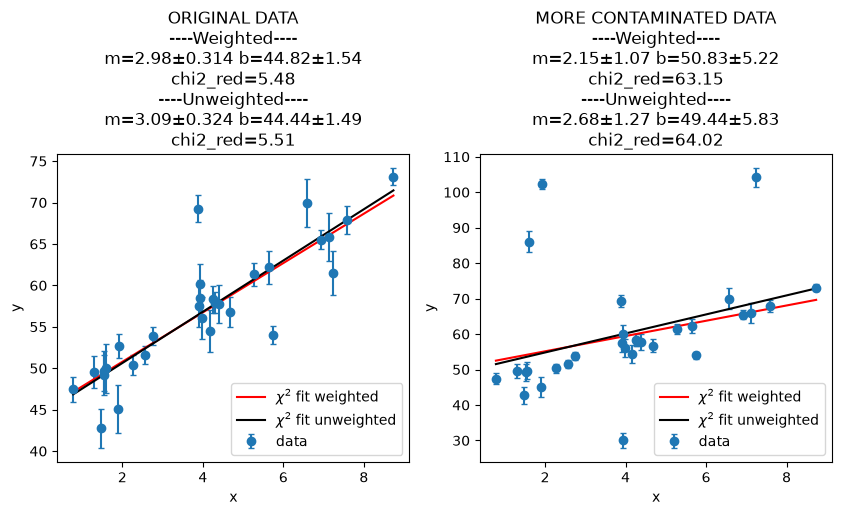

In [138]:
# Part 3: demonstrations here


#Flaw 1: unweighted fitting
#Plot two plots: one with the original data, and a new one with a deliberate contaminant
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

y = data['y']
p_naive, cov = np.polyfit(data['x'], y, 1, w=1/data['sigma_y'], cov=True)
p_naive_unw, cov_unw = np.polyfit(data['x'], y, 1, cov=True)

chi2 = np.sum(((y - np.polyval(p_naive, data['x'])) / data['sigma_y']) ** 2)
chi2_red = chi2 / (len(data) - 2)

chi2_unw = np.sum(((y - np.polyval(p_naive_unw, data['x'])) / data['sigma_y']) ** 2)
chi2_red_unw = chi2_unw / (len(data) - 2)

ax[0].set_title(f"ORIGINAL DATA\n----Weighted----\nm={p_naive[0]:.2f}"+r"$\pm$"+f"{np.sqrt(cov[0,0]):.3g} "+
          f"b={p_naive[1]:.2f}"+r"$\pm$"+f"{np.sqrt(cov[1,1]):.3g}\n" +
          f"chi2_red={chi2_red:.2f}\n"+
          f"----Unweighted----\nm={p_naive_unw[0]:.2f}"+r"$\pm$"+f"{np.sqrt(cov_unw[0,0]):.3g} "+
          f"b={p_naive_unw[1]:.2f}"+r"$\pm$"+f"{np.sqrt(cov_unw[1,1]):.3g}\n" +
          f"chi2_red={chi2_red_unw:.2f}")
xx = np.linspace(min(data['x']), max(data['x']), 200)
ax[0].errorbar(data['x'], y, yerr=data['sigma_y'], fmt='o', capsize=2, label='data')
ax[0].plot(xx, np.polyval(p_naive, xx), 'r-', label=r'$\chi^2$ fit weighted')
ax[0].plot(xx, np.polyval(p_naive_unw, xx), c='k', label=r'$\chi^2$ fit unweighted')
ax[0].set_xlabel('x'); ax[0].set_ylabel('y'); ax[0].legend()

#Now add random bad numbers i know are bad
rng = np.random.default_rng()
bad = rng.choice(len(y), size=4, replace=False)
y[bad] += rng.choice([-1, 1], size=4) * rng.uniform(0, 55, size=4)


p_naive, cov = np.polyfit(data['x'], y, 1, w=1/data['sigma_y'], cov=True)
p_naive_unw, cov_unw = np.polyfit(data['x'], y, 1, cov=True)

chi2 = np.sum(((y - np.polyval(p_naive, data['x'])) / data['sigma_y']) ** 2)
chi2_red = chi2 / (len(data) - 2)

chi2_unw = np.sum(((y - np.polyval(p_naive_unw, data['x'])) / data['sigma_y']) ** 2)
chi2_red_unw = chi2_unw / (len(data) - 2)

ax[1].set_title(f"MORE CONTAMINATED DATA\n----Weighted----\nm={p_naive[0]:.2f}"+r"$\pm$"+f"{np.sqrt(cov[0,0]):.3g} "+
          f"b={p_naive[1]:.2f}"+r"$\pm$"+f"{np.sqrt(cov[1,1]):.3g}\n" +
          f"chi2_red={chi2_red:.2f}\n"+
          f"----Unweighted----\nm={p_naive_unw[0]:.2f}"+r"$\pm$"+f"{np.sqrt(cov_unw[0,0]):.3g} "+
          f"b={p_naive_unw[1]:.2f}"+r"$\pm$"+f"{np.sqrt(cov_unw[1,1]):.3g}\n" +
          f"chi2_red={chi2_red_unw:.2f}")
xx = np.linspace(min(data['x']), max(data['x']), 200)
ax[1].errorbar(data['x'], y, yerr=data['sigma_y'], fmt='o', capsize=2, label='data')
ax[1].plot(xx, np.polyval(p_naive, xx), 'r-', label=r'$\chi^2$ fit weighted')
ax[1].plot(xx, np.polyval(p_naive_unw, xx), c='k', label=r'$\chi^2$ fit unweighted')
ax[1].set_xlabel('x'); ax[1].set_ylabel('y'); ax[1].legend()
plt.show()

It seems like choosing to weight or unweight the fit doesn't really impact the fit very much. This doesn't change if we use the original data vs if we use data with even more contaminants added in. In both datasets, the fitted parameters and the chi2_red look pretty similar between weighted and unweighted schemes, since the fit parameters are within each other's error.

3-sigma clip: slope=3.21, intercept=44.06, chi2_red=1.18, clipped 2 of 30 points
3-sigma clip: slope=3.02, intercept=44.17, chi2_red=3.50, clipped 1 of 30 points


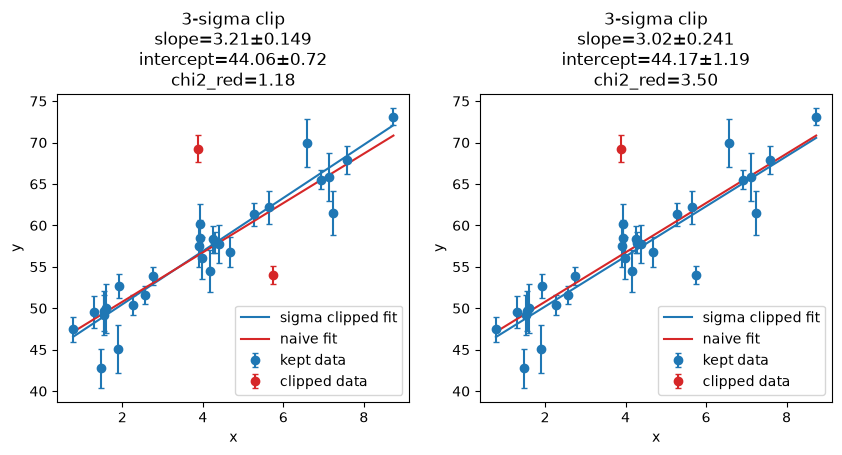

In [ ]:
# Flaw 2: sigma clips with distribution sigma instead of measurement error sigma

k=3

def sigma_clip_fit2(x, y, sigma, k, max_iter=10):
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        p, cov = np.polyfit(x[mask], y[mask], 1, w=1/sigma[mask], cov=True)
        
        resid = (y - np.polyval(p, x)) / np.std((y - np.polyval(p, x)))
        new_mask = np.abs(resid) < k
        if np.array_equal(new_mask, mask):
            break
        mask = new_mask
    return p, mask, cov

fig, ax = plt.subplots(1, 2, figsize = (10,4))
k=3
p_clip, mask, cov_clip = sigma_clip_fit(data['x'], data['y'], data['sigma_y'], k)
resid = data['y'][mask] - np.polyval(p_clip, data['x'][mask])
chi2_red_clip = np.sum((resid / data['sigma_y'][mask]) ** 2) / (mask.sum() - 2)
print(f"{k}-sigma clip: slope={p_clip[0]:.2f}, intercept={p_clip[1]:.2f}, "
    f"chi2_red={chi2_red_clip:.2f}, clipped {(~mask).sum()} of {len(data)} points")

p_clip2, mask2, cov_clip2 = sigma_clip_fit2(data['x'], data['y'], data['sigma_y'], k)
resid2 = data['y'][mask2] - np.polyval(p_clip, data['x'][mask2])
chi2_red_clip2 = np.sum((resid2 / data['sigma_y'][mask2]) ** 2) / (mask2.sum() - 2)
print(f"{k}-sigma clip: slope={p_clip2[0]:.2f}, intercept={p_clip2[1]:.2f}, "
    f"chi2_red={chi2_red_clip2:.2f}, clipped {(~mask2).sum()} of {len(data)} points")

ax[0].errorbar(data['x'][mask], data['y'][mask], yerr=data['sigma_y'][mask], 
            c='tab:blue', fmt='o', capsize=2, label='kept data')
ax[0].plot(data['x'], np.polyval(p_clip, data['x']), 
        c='tab:blue', label='sigma clipped fit')
ax[0].errorbar(data['x'][~mask], data['y'][~mask], yerr=data['sigma_y'][~mask], 
            c='tab:red', fmt='o', capsize=2, label='clipped data')
ax[0].plot(data['x'], np.polyval(p_naive, data['x']), 
        c='tab:red', label='naive fit')
ax[0].set_xlabel('x'); ax[0].set_ylabel('y'); ax[0].legend()
ax[0].set_title(f"{k}-sigma clip\n"+
        f"slope={p_clip[0]:.2f}"+r"$\pm$"+f"{np.sqrt(cov_clip[0,0]):.3g}\n"+
        f"intercept={p_clip[1]:.2f}"+r"$\pm$"+f"{np.sqrt(cov_clip[1,1]):.3g}\n" +
        f"chi2_red={chi2_red_clip:.2f}")
ax[1].errorbar(data['x'][mask2], data['y'][mask2], yerr=data['sigma_y'][mask2], 
            c='tab:blue', fmt='o', capsize=2, label='kept data')
ax[1].plot(data['x'], np.polyval(p_clip2, data['x']), 
        c='tab:blue', label='sigma clipped fit')
ax[1].errorbar(data['x'][~mask2], data['y'][~mask2], yerr=data['sigma_y'][~mask2], 
            c='tab:red', fmt='o', capsize=2, label='clipped data')
ax[1].plot(data['x'], np.polyval(p_naive, data['x']), 
        c='tab:red', label='naive fit')
ax[1].set_xlabel('x'); ax[1].set_ylabel('y'); ax[1].legend()
ax[1].set_title(f"{k}-sigma clip\n"+
        f"slope={p_clip2[0]:.2f}"+r"$\pm$"+f"{np.sqrt(cov_clip2[0,0]):.3g}\n"+
        f"intercept={p_clip2[1]:.2f}"+r"$\pm$"+f"{np.sqrt(cov_clip2[1,1]):.3g}\n" +
        f"chi2_red={chi2_red_clip2:.2f}")

plt.show()

Different sigma clipping algorithms will clip different datapoints. In this case, clipping different datapoints didn't actually change the fit that much, since the outliers in my data aren't egregiously off from the data and only nudges the fit a little

Text(0.5, 0.98, 'chi2_red changes with not only error, but also any outliers')

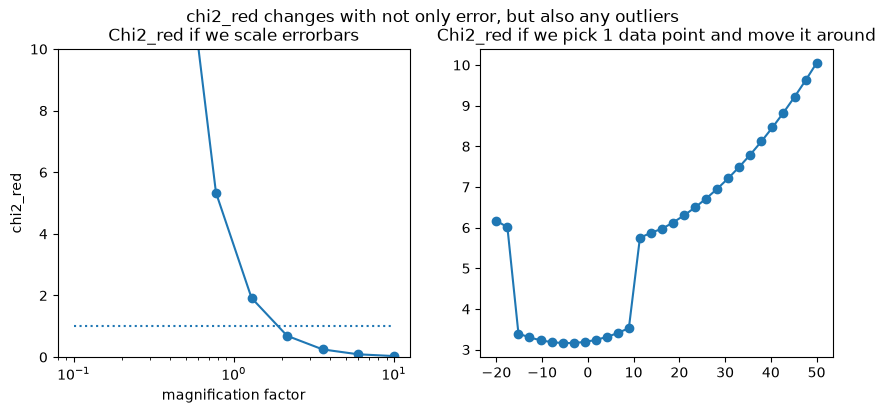

In [127]:
#Flaw 3: Wrong measurement error isn't the sole cause of chi2_red being large

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

chi2_red_scaleError = np.zeros(10)
k=3
scales=np.logspace(-1, 1, 10)
for i, scale in enumerate(scales):
    coeffs, cov = np.polyfit(data['x'], data['y'], 1, w=1/data['sigma_y']/scale, cov=True)
    m_fit, b_fit = coeffs
    m_err, b_err = np.sqrt(np.diag(cov))
    residuals = data['y'] - (m_fit * data['x'] + b_fit)
    threshold = 3 * np.std(residuals)
    mask = np.abs(residuals) < threshold
    chi2_ = np.sum(((data["y"][mask] - (m_fit * data["x"][mask] + b_fit)) / data['sigma_y'][mask]/scale)**2)
    chi2_red_ = chi2_ / (len(data)-2)
    chi2_red_scaleError[i] = chi2_red_
offsets = np.linspace(-20, 50, 30)
chi2_red_offset = np.zeros(len(offsets))
for i, offset in enumerate(offsets):
    y = data['y']
    y[0] += offset
    coeffs, cov = np.polyfit(data['x'], y, 1, w=1/data['sigma_y'], cov=True)
    m_fit, b_fit = coeffs
    m_err, b_err = np.sqrt(np.diag(cov))
    residuals = y - (m_fit * data['x'] + b_fit)
    threshold = 3 * np.std(residuals)
    mask = np.abs(residuals) < threshold
    chi2_ = np.sum(((data["y"][mask] - (m_fit * data["x"][mask] + b_fit)) / data['sigma_y'][mask])**2)
    chi2_red_ = chi2_ / (len(data)-2)
    chi2_red_offset[i] = chi2_red_

ax[0].set_title('Chi2_red if we scale errorbars')
ax[0].plot(scales, chi2_red_scaleError, marker='o')
ax[0].hlines(1, min(scales), max(scales), ls='dotted')
ax[0].set_xscale('log'); ax[0].set_ylim(0, 10)
ax[0].set_xlabel('magnification factor'); ax[0].set_ylabel('chi2_red')

ax[1].set_title('Chi2_red if we pick 1 data point and move it around')
ax[1].plot(offsets, chi2_red_offset, marker='o')
plt.suptitle('chi2_red changes with not only error, but also any outliers')

This demonstration proves that chi2_red is impacted by various factors. You can't simply conclude from a non-unity chi2_red that you have to scale errorbars. It's better practice to look at the data in different ways and try to diagnose the cause of chi2_red's non-unity.

## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
   what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
   is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers (e.g., residual plots, posterior/parameter sanity checks, refitting on synthetic
   data you generated with known answers). For each check: what would failure have looked like?

**AI-USE APPENDIX:**

I used chatgpt when i got a keyerror since i wrote data['sigma'] instead of data['sigma_y'] and was confused on what the error was saying.

The other tool i used was the day3_lecture.ipynb notebook.

**VERIFICATION PLAN:**

I examined the residuals of the mixture model. If my fit failed, then the residuals would have a nonzero slope.

I also looked at the distribution of p_bad of the mixture model. I wanted to figure out to what degree various points where considered outliers. I used this in order to choose that there are 2 contaminants in my data instead of 3, since for one of the points there's a 50% chance of it being a contaminant. If the fit failed, then i would find that normal linear-looking points are being labeled as contaminents